# 라이브러리 임포트

In [1]:
import pandas as pd
import numpy as np
import os

# 경로 설정

In [2]:
file_path_d = r"C:\Users\DME_Lab\DME Dropbox\장성우\Business Process Mining"

# 불러오기

In [3]:
# 이벤트 로그
event_log_pm = pd.read_csv(
    os.path.join(file_path_d, 'data', 'G01_eventlog.tsv'),
    sep='\t',
    index_col=0
)

C:\Users\DME_Lab\AppData\Local\Temp\ipykernel_32200\2757865436.py:2: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  event_log_pm = pd.read_csv(


In [4]:
# 출원 메타데이터
application = pd.read_csv(r"C:\Users\DME_Lab\Documents\수업\BPM\application_data.csv")

C:\Users\DME_Lab\AppData\Local\Temp\ipykernel_32200\1545909521.py:2: DtypeWarning: Columns (0,3,4,6,12,13,14,16,17,18,21) have mixed types. Specify dtype option on import or set low_memory=False.
  application = pd.read_csv(r"C:\Users\DME_Lab\Documents\수업\BPM\application_data.csv")


In [5]:
application

,application_number,filing_date,application_invention_type,examiner_full_name,examiner_art_unit,uspc_class,uspc_subclass,confirm_number,atty_docket_number,appl_status_desc,...,file_location_date,earliest_pgpub_number,earliest_pgpub_date,wipo_pub_number,wipo_pub_date,patent_number,patent_issue_date,invention_title,small_entity_indicator,aia_first_to_file
0,04453098,NaN,NaN,"LATEEF, MARVIN M",2106,338,254000,6933.0,NaN,Patented File - (Old Case Added for File Track...,...,1986-04-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,UNDISCOUNTED,NaN
1,04544040,NaN,NaN,"GLUCK, RICHARD E",3403,417,353000,9431.0,NaN,Patented File - (Old Case Added for File Track...,...,1999-06-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,UNDISCOUNTED,NaN
2,04577552,NaN,NaN,"LOOK, EDWARD K",3401,060,053000,1435.0,NaN,Patented File - (Old Case Added for File Track...,...,2008-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,UNDISCOUNTED,NaN
3,04589670,NaN,NaN,"NILSON, ROBERT G",3407,137,999999,1838.0,NaN,Patented File - (Old Case Added for File Track...,...,2008-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,UNDISCOUNTED,NaN
4,04578318,NaN,NaN,"HOWELL, DANIEL W",3722,409,163000,1455.0,NaN,ABANDONED - RESTORED,...,2016-11-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,UNDISCOUNTED,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14100373,17913164,2023-05-31,Utility,NaN,NaN,NaN,NaN,4063.0,GUH-504US,Sent to Classification contractor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,COMPOSITE CATALYST AND USE THEREOF IN PREPARIN...,SMALL,Other
14100374,17924829,2023-05-30,Utility,NaN,NaN,NaN,NaN,4148.0,50408-0067US1,Docketed New Case - Ready for Examination,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,METHOD AND DEVICE FOR ENCODING/DECODING IMAGE ...,UNDISCOUNTED,Other
14100375,17998169,2023-05-26,Utility,NaN,NaN,NaN,NaN,3435.0,5576.403,Sent to Classification contractor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PIEZOELECTRIC COMPOSITE SUBSTRATE AND METHOD F...,UNDISCOUNTED,Other
14100376,18005586,2023-05-25,Utility,NaN,NaN,NaN,NaN,2934.0,KODKA27.043AP,Sent to Classification contractor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ACTIVE ENERGY RAY-CURABLE INKJET PRINTING INK ...,UNDISCOUNTED,Other


In [6]:
event_log_pm

,application_number,event_code,recorded_date,event_desc,event_order
0,3757645,FLRCPT.O,1981-12-18,Filing Receipt,1
1,3757645,L132,1981-12-18,Secrecy Order Imposed,2
2,3757645,L133,1982-07-22,Secrecy Order Renewed,3
3,3757645,L133,1983-07-19,Secrecy Order Renewed,4
4,3757645,L133,1984-07-19,Secrecy Order Renewed,5
...,...,...,...,...,...
507392076,PCT/ZA22/50013,MP210,2022-05-23,Mail International Search Report,15
507392077,PCT/ZA22/50013,MICR,2022-07-22,Applicant Has Filed a Verified Statement of Mi...,16
507392078,PCT/ZA22/50013,SMAL,2022-07-22,Applicant Has Filed a Verified Statement of Sm...,17
507392079,PCT/ZA22/50013,P224,2022-08-17,General Communication - No Other Forms Applicable,18


In [7]:
# 1. Filing Receipt가 포함된 케이스 찾기
cases_with_fr = event_log_pm[event_log_pm['event_desc'] == 'Filing Receipt']['application_number'].unique()
print(f"Filing Receipt 포함된 케이스: {len(cases_with_fr)}")

Filing Receipt 포함된 케이스: 7380378


In [8]:
# 2. 그 케이스들 필터링
event_log_filtered = event_log_pm[event_log_pm['application_number'].isin(cases_with_fr)].copy()

In [9]:
# 3. 날짜순 정렬
event_log_filtered = event_log_filtered.sort_values(['application_number', 'recorded_date']).reset_index(drop=True)

In [10]:
event_log_filtered

,application_number,event_code,recorded_date,event_desc,event_order
0,3757645,FLRCPT.O,1981-12-18,Filing Receipt,1
1,3757645,L132,1981-12-18,Secrecy Order Imposed,2
2,3757645,L133,1982-07-22,Secrecy Order Renewed,3
3,3757645,L133,1983-07-19,Secrecy Order Renewed,4
4,3757645,L133,1984-07-19,Secrecy Order Renewed,5
...,...,...,...,...,...
325728822,96000055,MRSEN,2015-11-16,SE - Mail Notice of Intent to Issue Reexam Cer...,27
325728823,96000055,MREXN,2015-12-01,RX - Mail Examiner Interview Summary Record,28
325728824,96000055,MRSEN,2015-12-01,SE - Mail Notice of Intent to Issue Reexam Cer...,29
325728825,96000055,REEX,2015-12-04,Input Issue Number and Issue Date for Reexamin...,30


In [11]:
# Filing Receipt의 event_order 찾기
filing_order = (
    event_log_filtered
    .loc[event_log_filtered['event_desc'].eq('Filing Receipt'),
         ['application_number', 'event_order']]
    .rename(columns={'event_order': 'filing_receipt_order'})
)

# 원본에 붙이기
event_log_filtered2 = event_log_filtered.merge(
    filing_order,
    on='application_number',
    how='left'
)

# Filing Receipt 이전 이벤트 drop
event_log_filtered2 = event_log_filtered2[
    event_log_filtered2['event_order'] >= event_log_filtered2['filing_receipt_order']
].copy()

# 필요 없으면 기준 컬럼 제거
event_log_filtered2 = event_log_filtered2.drop(columns='filing_receipt_order')

In [12]:
event_log_filtered2

,application_number,event_code,recorded_date,event_desc,event_order
0,3757645,FLRCPT.O,1981-12-18,Filing Receipt,1
1,3757645,L132,1981-12-18,Secrecy Order Imposed,2
2,3757645,L133,1982-07-22,Secrecy Order Renewed,3
3,3757645,L133,1983-07-19,Secrecy Order Renewed,4
4,3757645,L133,1984-07-19,Secrecy Order Renewed,5
...,...,...,...,...,...
330581059,96000055,MRSEN,2015-11-16,SE - Mail Notice of Intent to Issue Reexam Cer...,27
330581060,96000055,MREXN,2015-12-01,RX - Mail Examiner Interview Summary Record,28
330581061,96000055,MRSEN,2015-12-01,SE - Mail Notice of Intent to Issue Reexam Cer...,29
330581062,96000055,REEX,2015-12-04,Input Issue Number and Issue Date for Reexamin...,30


In [13]:
# application_number 형식 통일
event_log_filtered2['application_number'] = event_log_filtered2['application_number'].astype(str).str.zfill(8)
application['application_number'] = application['application_number'].astype(str).str.zfill(8)

In [14]:
# merge
df_merged = event_log_filtered2.merge(
    application[['application_number', 'filing_date', 'patent_issue_date', 'appl_status_desc']],
    on='application_number',
    how='inner'
)

In [15]:
df_merged

,application_number,event_code,recorded_date,event_desc,event_order,filing_date,patent_issue_date,appl_status_desc
0,03757645,FLRCPT.O,1981-12-18,Filing Receipt,1,1981-12-18,1997-10-21,Patent Expired Due to NonPayment of Maintenanc...
1,03757645,L132,1981-12-18,Secrecy Order Imposed,2,1981-12-18,1997-10-21,Patent Expired Due to NonPayment of Maintenanc...
2,03757645,L133,1982-07-22,Secrecy Order Renewed,3,1981-12-18,1997-10-21,Patent Expired Due to NonPayment of Maintenanc...
3,03757645,L133,1983-07-19,Secrecy Order Renewed,4,1981-12-18,1997-10-21,Patent Expired Due to NonPayment of Maintenanc...
4,03757645,L133,1984-07-19,Secrecy Order Renewed,5,1981-12-18,1997-10-21,Patent Expired Due to NonPayment of Maintenanc...
...,...,...,...,...,...,...,...,...
250371763,96000055,MRSEN,2015-11-16,SE - Mail Notice of Intent to Issue Reexam Cer...,27,2014-02-18,NaN,Intent to Issue Certificate based on Supplemen...
250371764,96000055,MREXN,2015-12-01,RX - Mail Examiner Interview Summary Record,28,2014-02-18,NaN,Intent to Issue Certificate based on Supplemen...
250371765,96000055,MRSEN,2015-12-01,SE - Mail Notice of Intent to Issue Reexam Cer...,29,2014-02-18,NaN,Intent to Issue Certificate based on Supplemen...
250371766,96000055,REEX,2015-12-04,Input Issue Number and Issue Date for Reexamin...,30,2014-02-18,NaN,Intent to Issue Certificate based on Supplemen...


In [16]:
df_merged['appl_status_desc'].value_counts()

appl_status_desc
Patented Case                                                              159096926
Abandoned -- Failure to Respond to an Office Action                         38948911
Patent Expired Due to NonPayment of Maintenance Fees Under 37 CFR 1.362     25698947
Docketed New Case - Ready for Examination                                    5066773
Non Final Action Mailed                                                      3690404
                                                                             ...    
Hague Application under International Review                                       8
Rocket Docket                                                                      7
Pre-Exam Transmittal Review Complete (Hague)                                       2
Reexam Assigned to Examiner for Determination                                      1
Request for Reexamination Denied                                                   1
Name: count, Length: 70, dtype: int64

In [17]:
# patent_issue_date가 있는 케이스만 (진정한 grant)
df_granted = df_merged[df_merged['patent_issue_date'].notna()].copy()

print(f"Patent issued 케이스: {df_granted['application_number'].nunique()}")
print(f"Events: {len(df_granted)}")
print(f"\nStatus 분포:")
print(df_granted['appl_status_desc'].value_counts().head(10))

Patent issued 케이스: 4128439
Events: 184662321

Status 분포:
appl_status_desc
Patented Case                                                                   158353241
Patent Expired Due to NonPayment of Maintenance Fees Under 37 CFR 1.362          25698885
Court Proceedings Terminated                                                         3525
Application Involved in Court Proceedings                                            1373
Awaiting TC Resp., Issue Fee Not Paid                                                 801
Docketed New Case - Ready for Examination                                             330
Notice of Allowance Mailed -- Application Received in Office of Publications          236
Abandoned -- Failure to Pay Issue Fee                                                 110
Withdraw from issue awaiting action                                                   110
Expressly Abandoned -- During Examination                                              55
Name: count, dtype: int64


## Grant case

In [18]:
# 날짜 변환 (format='mixed' 사용)
df_granted['recorded_date'] = pd.to_datetime(df_granted['recorded_date'], format='mixed', errors='coerce')
df_granted['patent_issue_date'] = pd.to_datetime(df_granted['patent_issue_date'], format='mixed', errors='coerce')

print(f"recorded_date dtype: {df_granted['recorded_date'].dtype}")
print(f"patent_issue_date dtype: {df_granted['patent_issue_date'].dtype}")

# 확인
print(df_granted[['recorded_date', 'patent_issue_date']].head())

recorded_date dtype: datetime64[ns]
patent_issue_date dtype: datetime64[ns]
  recorded_date patent_issue_date
0    1981-12-18        1997-10-21
1    1981-12-18        1997-10-21
2    1982-07-22        1997-10-21
3    1983-07-19        1997-10-21
4    1984-07-19        1997-10-21


In [19]:
# recorded_date와 patent_issue_date가 같은 날짜인 이벤트들
same_date_events = df_granted[
    df_granted['recorded_date'].dt.date == df_granted['patent_issue_date'].dt.date
]

print(f"Issue date와 같은 날짜 이벤트: {len(same_date_events)}")
print(f"\n이벤트 타입 (issue date 당일):")
print(same_date_events['event_desc'].value_counts())

# 코드도 확인
print(f"\n이벤트 코드:")
print(same_date_events['event_code'].value_counts())

Issue date와 같은 날짜 이벤트: 8500272

이벤트 타입 (issue date 당일):
event_desc
Recordation of Patent Grant Mailed                                   4163091
Patent Issue Date Used in PTA Calculation                            3763132
Application ready for PDX access by participating foreign offices     309835
Sequence Moved to Public Database                                      62325
Recordation of Patent eGrant                                           47963
                                                                      ...   
Payment of Maintenance Fee, 12th Yr, Small Entity                          1
Refund - Payment of Maintenance Fee under 1.28(c)                          1
Payment of Maintenance Fee under 1.28(c)                                   1
Mail-Petition to Revive Application - Granted                              1
Mail Third Party IDS communication                                         1
Name: count, Length: 135, dtype: int64

이벤트 코드:
event_code
PGM/     4163091
PTAC     3

In [20]:
# Recordation of Patent Grant Mailed가 있는 케이스
pgm_cases = df_granted[df_granted['event_desc'] == 'Recordation of Patent Grant Mailed']['application_number'].unique()

print(f"현재 df_granted 고유 케이스: {df_granted['application_number'].nunique()}")
print(f"'Recordation of Patent Grant Mailed' 포함 케이스: {len(pgm_cases)}")


현재 df_granted 고유 케이스: 4128439
'Recordation of Patent Grant Mailed' 포함 케이스: 4126947


In [21]:
# Recordation of Patent Grant Mailed의 event_order를 케이스별로 찾기
pgm_orders = df_granted[df_granted['event_desc'] == 'Recordation of Patent Grant Mailed'].groupby('application_number')['event_order'].min()

# 그 케이스들만 + Recordation 이전까지만
df_granted_final = df_granted[df_granted['application_number'].isin(pgm_orders.index)].copy()

# event_order <= pgm_order인 것만
df_granted_final = df_granted_final.merge(
    pgm_orders.reset_index().rename(columns={'event_order': 'pgm_order'}),
    on='application_number'
)
df_granted_final = df_granted_final[df_granted_final['event_order'] <= df_granted_final['pgm_order']].drop('pgm_order', axis=1)

In [22]:
df_granted_final

,application_number,event_code,recorded_date,event_desc,event_order,filing_date,patent_issue_date,appl_status_desc
0,03757645,FLRCPT.O,1981-12-18,Filing Receipt,1,1981-12-18,1997-10-21,Patent Expired Due to NonPayment of Maintenanc...
1,03757645,L132,1981-12-18,Secrecy Order Imposed,2,1981-12-18,1997-10-21,Patent Expired Due to NonPayment of Maintenanc...
2,03757645,L133,1982-07-22,Secrecy Order Renewed,3,1981-12-18,1997-10-21,Patent Expired Due to NonPayment of Maintenanc...
3,03757645,L133,1983-07-19,Secrecy Order Renewed,4,1981-12-18,1997-10-21,Patent Expired Due to NonPayment of Maintenanc...
4,03757645,L133,1984-07-19,Secrecy Order Renewed,5,1981-12-18,1997-10-21,Patent Expired Due to NonPayment of Maintenanc...
...,...,...,...,...,...,...,...,...
184610047,35515323,PILS,2023-03-17,Application Is Considered Ready for Issue,19,2022-08-12,2023-04-18,Patented Case
184610048,35515323,WPIR,2023-03-29,Issue Notification Mailed,20,2022-08-12,2023-04-18,Patented Case
184610049,35515323,CCRDY,2023-03-30,Application ready for PDX access by participat...,21,2022-08-12,2023-04-18,Patented Case
184610050,35515323,STGR,2023-04-18,Statement Of Grant (Hague),22,2022-08-12,2023-04-18,Patented Case


In [23]:
# df_granted_final에 메타데이터 추가
keep_cols = ['application_number', 'examiner_full_name', 'examiner_art_unit', 
             'patent_number']

# Merge
df_granted_with_meta = df_granted_final.merge(
    application[keep_cols],
    on='application_number',
    how='left'
)

print(f"\n최종 컬럼:")
print(df_granted_with_meta.columns.tolist())
print(f"\nShape: {df_granted_with_meta.shape}")
print(f"Cases: {df_granted_with_meta['application_number'].nunique()}")


최종 컬럼:
['application_number', 'event_code', 'recorded_date', 'event_desc', 'event_order', 'filing_date', 'patent_issue_date', 'appl_status_desc', 'examiner_full_name', 'examiner_art_unit', 'patent_number']

Shape: (174178521, 11)
Cases: 4126947


In [24]:
df_granted_with_meta

,application_number,event_code,recorded_date,event_desc,event_order,filing_date,patent_issue_date,appl_status_desc,examiner_full_name,examiner_art_unit,patent_number
0,03757645,FLRCPT.O,1981-12-18,Filing Receipt,1,1981-12-18,1997-10-21,Patent Expired Due to NonPayment of Maintenanc...,"NELSON, PETER A",3641,5679921
1,03757645,L132,1981-12-18,Secrecy Order Imposed,2,1981-12-18,1997-10-21,Patent Expired Due to NonPayment of Maintenanc...,"NELSON, PETER A",3641,5679921
2,03757645,L133,1982-07-22,Secrecy Order Renewed,3,1981-12-18,1997-10-21,Patent Expired Due to NonPayment of Maintenanc...,"NELSON, PETER A",3641,5679921
3,03757645,L133,1983-07-19,Secrecy Order Renewed,4,1981-12-18,1997-10-21,Patent Expired Due to NonPayment of Maintenanc...,"NELSON, PETER A",3641,5679921
4,03757645,L133,1984-07-19,Secrecy Order Renewed,5,1981-12-18,1997-10-21,Patent Expired Due to NonPayment of Maintenanc...,"NELSON, PETER A",3641,5679921
...,...,...,...,...,...,...,...,...,...,...,...
174178516,35515323,PILS,2023-03-17,Application Is Considered Ready for Issue,19,2022-08-12,2023-04-18,Patented Case,"PHILIPPS, MARK T",2915,D983840
174178517,35515323,WPIR,2023-03-29,Issue Notification Mailed,20,2022-08-12,2023-04-18,Patented Case,"PHILIPPS, MARK T",2915,D983840
174178518,35515323,CCRDY,2023-03-30,Application ready for PDX access by participat...,21,2022-08-12,2023-04-18,Patented Case,"PHILIPPS, MARK T",2915,D983840
174178519,35515323,STGR,2023-04-18,Statement Of Grant (Hague),22,2022-08-12,2023-04-18,Patented Case,"PHILIPPS, MARK T",2915,D983840


In [25]:
df_granted_with_meta['patent_number'].nunique()

4126947

In [28]:
# 결측값 확인
print("=== Missing Values ===\n")
missing = df_granted_with_meta.isnull().sum()
missing_pct = 100 * missing / len(df_granted_with_meta)

missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing Count': missing.values,
    'Missing %': missing_pct.values
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

if len(missing_df) > 0:
    print(missing_df.to_string())
else:
    print("결측값 없음!")

=== Missing Values ===

               Column  Missing Count  Missing %
7    appl_status_desc         583280   0.334875
8  examiner_full_name              6   0.000003


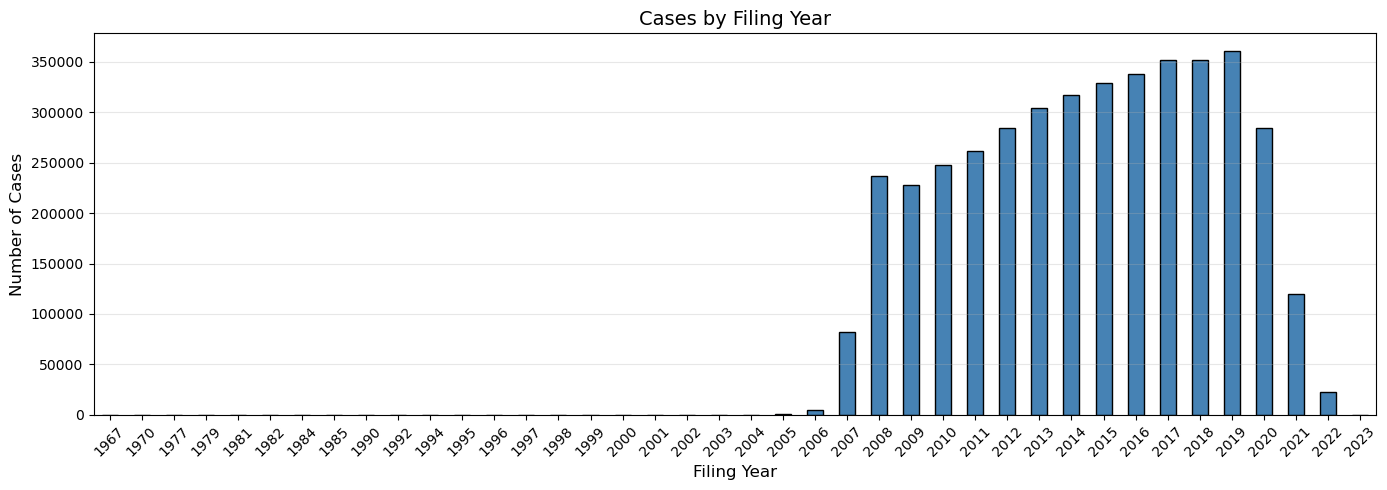

Total cases: 4,126,947

Cases by year:
filing_year
1967         2
1970         3
1977         1
1979         2
1981         6
1982         8
1984         1
1985         1
1990         1
1992         1
1994         2
1995         3
1996         5
1997         5
1998         5
1999        16
2000        10
2001        10
2002         8
2003        42
2004        82
2005       260
2006      4845
2007     82437
2008    236821
2009    228024
2010    247289
2011    261711
2012    284960
2013    304086
2014    317131
2015    328691
2016    337910
2017    352156
2018    352195
2019    360398
2020    284931
2021    119912
2022     22762
2023       214
Name: application_number, dtype: int64


In [29]:
import matplotlib.pyplot as plt

# 년도별 케이스 개수
cases_by_year = df_granted_with_meta.groupby('filing_year')['application_number'].nunique()

# 시각화
fig, ax = plt.subplots(figsize=(14, 5))
cases_by_year.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('Filing Year', fontsize=12)
ax.set_ylabel('Number of Cases', fontsize=12)
ax.set_title('Cases by Filing Year', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total cases: {cases_by_year.sum():,}")
print(f"\nCases by year:")
print(cases_by_year)


In [30]:
df_final = df_granted_with_meta[
    (df_granted_with_meta['filing_year'] >= 2008) & 
    (df_granted_with_meta['filing_year'] <= 2015)
].copy()

In [31]:
df_final

,application_number,event_code,recorded_date,event_desc,event_order,filing_date,patent_issue_date,appl_status_desc,examiner_full_name,examiner_art_unit,patent_number,filing_year
2051,09786529,FLRCPT.O,2010-10-27,Filing Receipt,28,2010-10-08,2014-03-18,Patent Expired Due to NonPayment of Maintenanc...,"O CONNOR, BRIAN T",2475,8675647,2010
2052,09786529,M903,2010-10-27,Notice of DO/EO Acceptance Mailed,29,2010-10-08,2014-03-18,Patent Expired Due to NonPayment of Maintenanc...,"O CONNOR, BRIAN T",2475,8675647,2010
2053,09786529,MPEN,2011-01-18,Mail Pre-Exam Notice,30,2010-10-08,2014-03-18,Patent Expired Due to NonPayment of Maintenanc...,"O CONNOR, BRIAN T",2475,8675647,2010
2054,09786529,OIPE,2011-01-18,Application Dispatched from OIPE,31,2010-10-08,2014-03-18,Patent Expired Due to NonPayment of Maintenanc...,"O CONNOR, BRIAN T",2475,8675647,2010
2055,09786529,ROIPE,2011-01-18,Application Return TO OIPE,32,2010-10-08,2014-03-18,Patent Expired Due to NonPayment of Maintenanc...,"O CONNOR, BRIAN T",2475,8675647,2010
...,...,...,...,...,...,...,...,...,...,...,...,...
173917554,35501394,EML_NTR,2018-07-19,Email Notification,46,2015-10-20,2018-08-07,Patented Case,"ALBERT, ELIZABETH",2913,D824745,2015
173917555,35501394,CCRDY,2018-07-19,Application ready for PDX access by participat...,47,2015-10-20,2018-08-07,Patented Case,"ALBERT, ELIZABETH",2913,D824745,2015
173917556,35501394,NOIFIBHA,2018-07-20,Issue Fee not Paid Directly to I.B. (Hague),48,2015-10-20,2018-08-07,Patented Case,"ALBERT, ELIZABETH",2913,D824745,2015
173917557,35501394,STGR,2018-08-07,Statement Of Grant (Hague),49,2015-10-20,2018-08-07,Patented Case,"ALBERT, ELIZABETH",2913,D824745,2015


In [ ]:
df_final = df_final.drop(columns=['appl_status_desc', 'filing_date', 'patent_issue_date'])

# SAVE

In [ ]:
df_final.to_csv(os.path.join(file_path_d, 'data', 'G02_granted_cases.tsv'), sep='\t', index=False)